# EV Grid Stress Analysis & Visualization

Comprehensive analysis of EV Grid Stress Monitoring and Prediction System datasets, including visualization of charging patterns, grid load dynamics, and predictive features.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import json
import os
import warnings

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style for visualization
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ All libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.1.3


## 2. Define Indian States Configuration

In [2]:
# Define all 28 Indian states
INDIAN_STATES = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh',
    'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand',
    'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
    'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab',
    'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
    'Uttar Pradesh', 'Uttarakhand', 'West Bengal'
]

print(f"✓ Defined {len(INDIAN_STATES)} Indian states for analysis")
print(f"States: {', '.join(INDIAN_STATES[:5])}... and {len(INDIAN_STATES)-5} more")

✓ Defined 28 Indian states for analysis
States: Andhra Pradesh, Arunachal Pradesh, Assam, Bihar, Chhattisgarh... and 23 more


## 3. Load Real EV Grid Stress Dataset

In [3]:
print("Loading EV Grid Stress Dataset...")

# Load the real dataset from CSV
df_main = pd.read_csv('../data/ev_grid_stress_dataset.csv')
df_main['timestamp'] = pd.to_datetime(df_main['timestamp'])

print(f"✓ Loaded: ev_grid_stress_dataset.csv ({len(df_main)} rows, {len(df_main.columns)} columns)")
print(f"Shape: {df_main.shape}")
print(f"Date Range: {df_main['timestamp'].min()} to {df_main['timestamp'].max()}")
print(f"States: {df_main['state'].nunique()}")

# Convert categorical overload_risk to numeric
print("\nConverting overload_risk to numeric values...")
print(f"Original values: {df_main['overload_risk'].unique()}")

# Map risk levels to numeric values
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 1}
df_main['overload_risk'] = df_main['overload_risk'].map(risk_mapping).astype(int)

print(f"✓ Converted overload_risk to numeric: {df_main['overload_risk'].unique()}")

print(f"\nMissing Values:")
print(df_main.isnull().sum()[df_main.isnull().sum() > 0])
print(f"\nFirst few rows:")
df_main.head()

Loading EV Grid Stress Dataset...
✓ Loaded: ev_grid_stress_dataset.csv (8760 rows, 18 columns)
Shape: (8760, 18)
Date Range: 2024-01-01 00:00:00 to 2024-12-30 23:00:00
States: 28

Converting overload_risk to numeric values...
Original values: ['Low' 'Medium' 'High']
✓ Converted overload_risk to numeric: [0 1]

Missing Values:
Series([], dtype: int64)

First few rows:


,timestamp,state,total_charging_stations,fast_chargers,slow_chargers,charging_sessions,energy_consumed_kwh,grid_load_mw,voltage_v,frequency_hz,transformer_load_percent,renewable_share_percent,hour,day_of_week,ev_population,charger_ev_ratio,peak_hour_flag,overload_risk
0,2024-01-01 00:00:00,Gujarat,485,164,321,156,2361.213349,7302.751106,225.415866,49.993793,54.051241,20.016888,0,0,16523,34.068041,0,0
1,2024-01-01 01:00:00,Assam,358,123,235,343,1718.472517,10219.880915,237.311891,50.076936,68.105144,6.037809,1,0,26158,73.067039,0,1
2,2024-01-01 02:00:00,Jharkhand,525,180,345,320,3497.251134,8752.231730,230.337641,49.928763,66.402159,7.090269,2,0,4390,8.361905,0,1
3,2024-01-01 03:00:00,Gujarat,70,16,54,323,5599.370371,10017.824232,226.998731,50.047372,68.020969,35.790486,3,0,23983,342.614286,0,1
4,2024-01-01 04:00:00,Gujarat,477,118,359,84,1412.977879,4878.659871,223.674404,50.054600,37.648591,29.601963,4,0,10192,21.366876,0,0


## 4. Data Overview

In [4]:
print("Dataset Summary:")
print(f"Shape: {df_main.shape} ({df_main.shape[0]} rows, {df_main.shape[1]} columns)")
print(f"\nDate Range: {df_main['timestamp'].min()} to {df_main['timestamp'].max()}")
print(f"Number of States: {df_main['state'].nunique()}")
print(f"\nColumn Names:")
print(df_main.columns.tolist())
print(f"\nData Types:")
print(df_main.dtypes)
print(f"\nMissing Values:")
missing = df_main.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")
print(f"\nBasic Statistics:")
df_main.describe()

Dataset Summary:
Shape: (8760, 18) (8760 rows, 18 columns)

Date Range: 2024-01-01 00:00:00 to 2024-12-30 23:00:00
Number of States: 28

Column Names:
['timestamp', 'state', 'total_charging_stations', 'fast_chargers', 'slow_chargers', 'charging_sessions', 'energy_consumed_kwh', 'grid_load_mw', 'voltage_v', 'frequency_hz', 'transformer_load_percent', 'renewable_share_percent', 'hour', 'day_of_week', 'ev_population', 'charger_ev_ratio', 'peak_hour_flag', 'overload_risk']

Data Types:
timestamp                   datetime64[ns]
state                               object
total_charging_stations              int64
fast_chargers                        int64
slow_chargers                        int64
charging_sessions                    int64
energy_consumed_kwh                float64
grid_load_mw                       float64
voltage_v                          float64
frequency_hz                       float64
transformer_load_percent           float64
renewable_share_percent            float

,timestamp,total_charging_stations,fast_chargers,slow_chargers,charging_sessions,energy_consumed_kwh,grid_load_mw,voltage_v,frequency_hz,transformer_load_percent,renewable_share_percent,hour,day_of_week,ev_population,charger_ev_ratio,peak_hour_flag,overload_risk
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2024-07-01 11:30:00,372.811986,92.493721,280.318265,379.557991,4388.332342,6772.300348,230.125474,49.999892,50.868376,27.503824,11.500000,2.991781,20317.880822,83.102332,0.208333,0.322260
min,2024-01-01 00:00:00,50.000000,7.000000,33.000000,50.000000,266.153905,3058.195461,212.655418,49.819617,17.117622,5.015830,0.000000,0.000000,506.000000,0.792151,0.000000,0.000000
25%,2024-04-01 05:45:00,210.000000,49.000000,157.000000,171.000000,1733.223712,5025.220984,226.730395,49.966127,38.299727,16.110981,5.750000,1.000000,10368.250000,28.027626,0.000000,0.000000
50%,2024-07-01 11:30:00,372.000000,87.000000,279.000000,287.000000,3158.123948,6749.469600,230.075900,49.999442,50.858128,27.520457,11.500000,3.000000,20435.000000,54.464233,0.000000,0.000000
75%,2024-09-30 17:15:00,535.000000,129.000000,398.000000,537.000000,5624.608651,8549.741522,233.513121,50.033068,63.639484,38.751707,17.250000,5.000000,30292.000000,97.014103,0.000000,1.000000
max,2024-12-30 23:00:00,699.000000,243.000000,591.000000,1198.000000,20898.241115,10920.522730,248.012075,50.196312,85.938586,49.993376,23.000000,6.000000,39993.000000,766.920000,1.000000,1.000000
std,NaN,188.005879,53.040541,142.843164,283.087493,3746.089095,2050.518834,5.065435,0.050454,15.272264,13.014932,6.922582,2.003519,11474.650674,94.651723,0.406140,0.467369


## 5. EV Charging Sessions Distribution

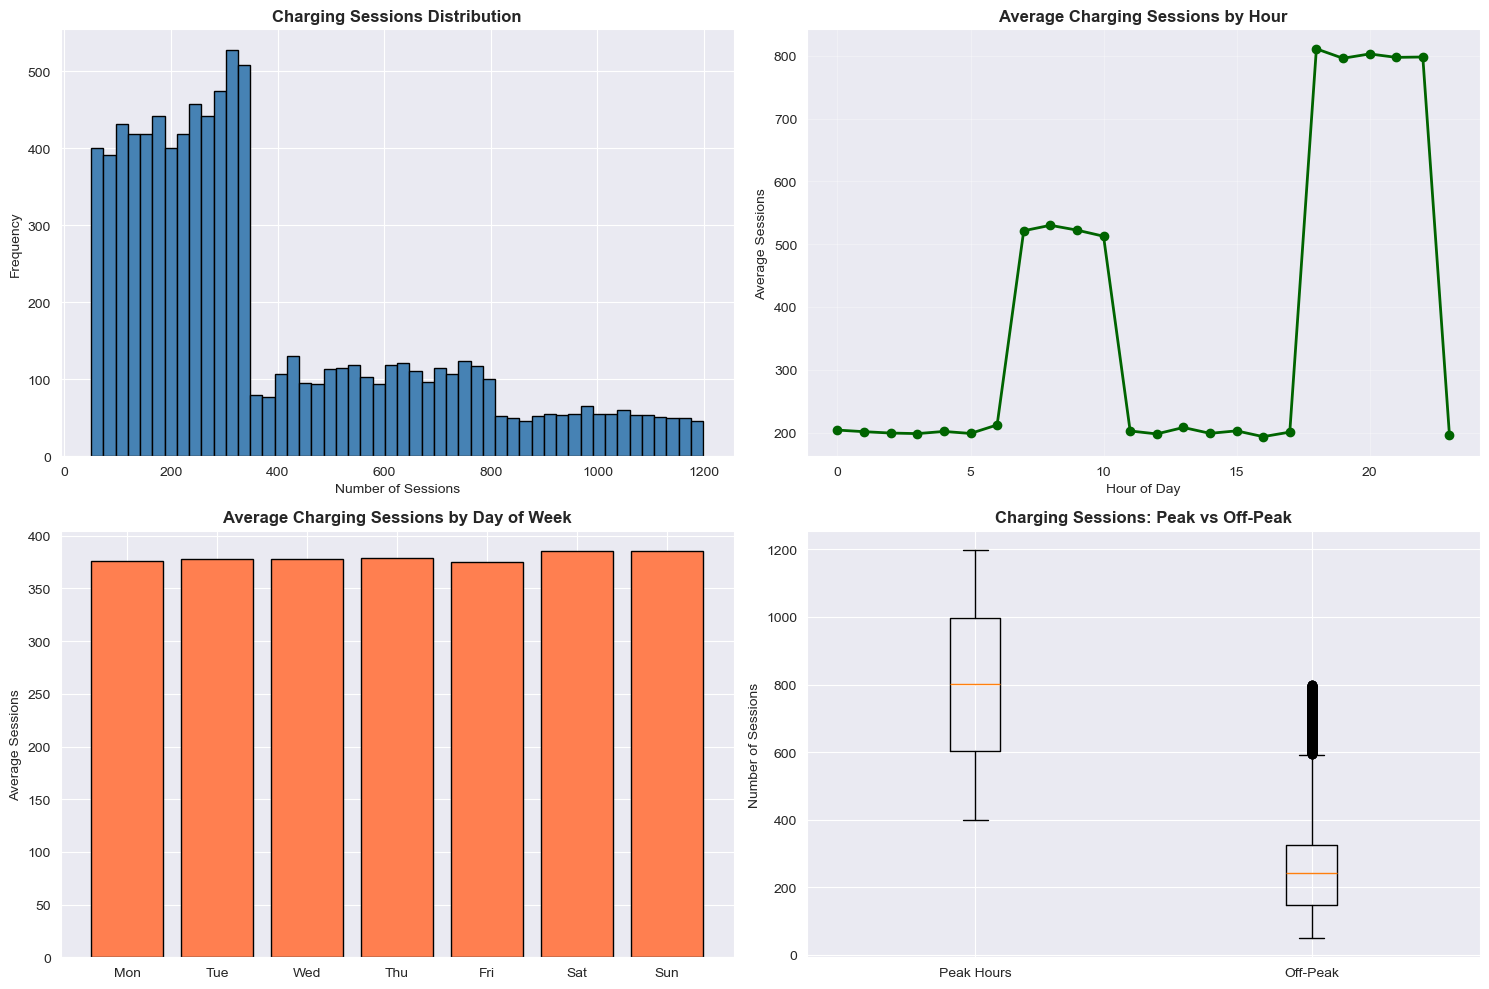

✓ Charging Sessions Analysis Complete


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of charging sessions
axes[0, 0].hist(df_main['charging_sessions'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Charging Sessions Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Sessions')
axes[0, 0].set_ylabel('Frequency')

# Distribution by hour of day
hourly = df_main.groupby('hour')['charging_sessions'].mean()
axes[0, 1].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='darkgreen')
axes[0, 1].set_title('Average Charging Sessions by Hour', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Average Sessions')
axes[0, 1].grid(True, alpha=0.3)

# Distribution by day of week
weekly = df_main.groupby('day_of_week')['charging_sessions'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(days, weekly.values, color='coral', edgecolor='black')
axes[1, 0].set_title('Average Charging Sessions by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Sessions')

# Box plot by peak hour
df_main['period'] = df_main['peak_hour_flag'].apply(lambda x: 'Peak Hours' if x == 1 else 'Off-Peak')
data_to_plot = [df_main[df_main['period'] == 'Peak Hours']['charging_sessions'],
                df_main[df_main['period'] == 'Off-Peak']['charging_sessions']]
axes[1, 1].boxplot(data_to_plot, labels=['Peak Hours', 'Off-Peak'])
axes[1, 1].set_title('Charging Sessions: Peak vs Off-Peak', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Sessions')

plt.tight_layout()
plt.show()

print("✓ Charging Sessions Analysis Complete")

## 6. State-wise Charger Distribution

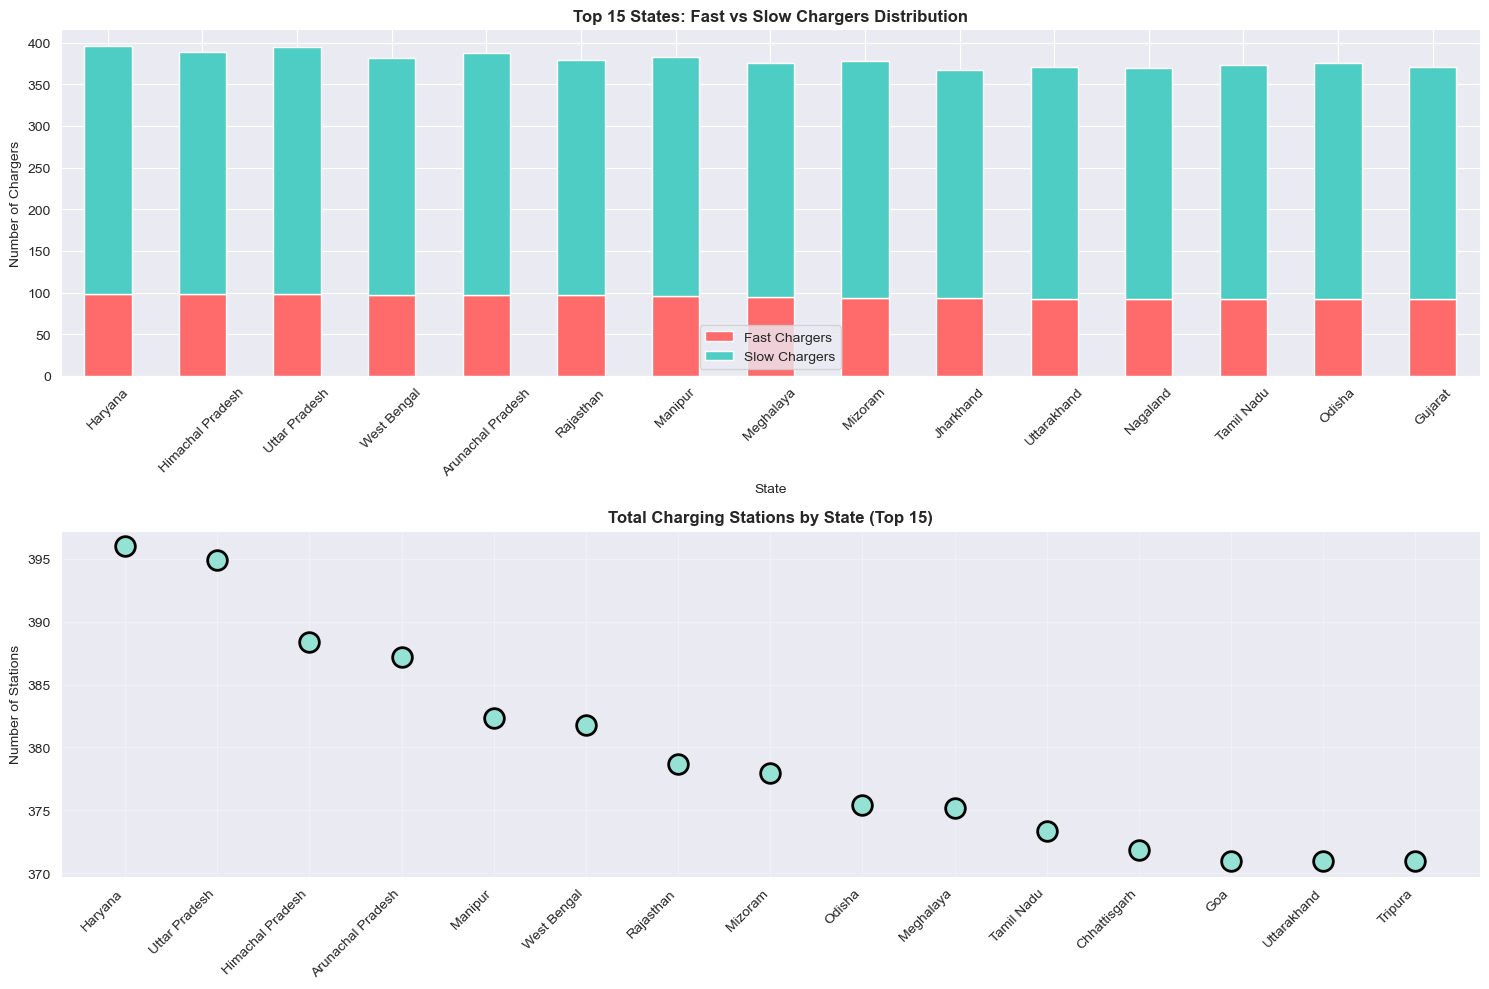

✓ State-wise Charger Distribution Analysis Complete


In [6]:
# State-wise aggregation
state_chargers = df_main.groupby('state')[['fast_chargers', 'slow_chargers']].mean()
state_chargers = state_chargers.sort_values('fast_chargers', ascending=False).head(15)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Stacked bar chart
state_chargers.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Top 15 States: Fast vs Slow Chargers Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Chargers')
axes[0].legend(['Fast Chargers', 'Slow Chargers'])
axes[0].tick_params(axis='x', rotation=45)

# Scatter plot: Total chargers vs State
state_total = df_main.groupby('state')['total_charging_stations'].mean().sort_values(ascending=False).head(15)
axes[1].scatter(range(len(state_total)), state_total.values, s=200, color='#95E1D3', edgecolor='black', linewidth=2)
axes[1].set_xticks(range(len(state_total)))
axes[1].set_xticklabels(state_total.index, rotation=45, ha='right')
axes[1].set_title('Total Charging Stations by State (Top 15)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Stations')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ State-wise Charger Distribution Analysis Complete")

## 7. Grid Load vs Charging Sessions Relationship

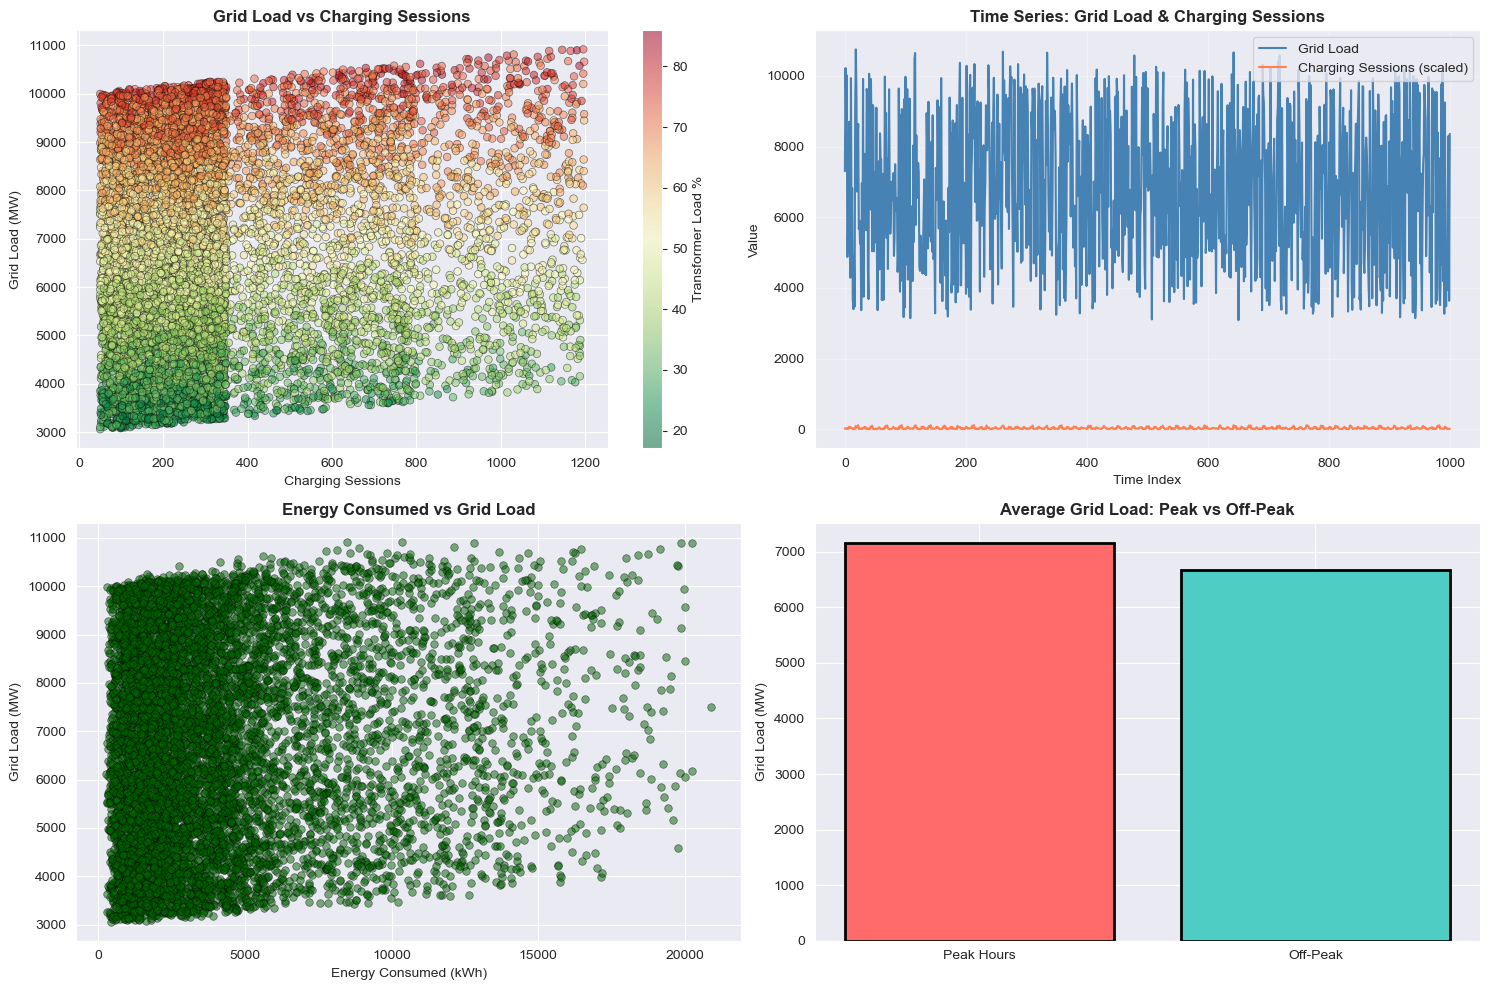

✓ Grid Load Analysis Complete


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Scatter: Grid Load vs Charging Sessions
axes[0, 0].scatter(df_main['charging_sessions'], df_main['grid_load_mw'], 
                   alpha=0.5, s=30, c=df_main['transformer_load_percent'], 
                   cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[0, 0].set_title('Grid Load vs Charging Sessions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Charging Sessions')
axes[0, 0].set_ylabel('Grid Load (MW)')
cbar = plt.colorbar(axes[0, 0].collections[0], ax=axes[0, 0])
cbar.set_label('Transformer Load %')

# Line plot: Trend over index
axes[0, 1].plot(df_main.index[:1000], df_main['grid_load_mw'].iloc[:1000], 
                label='Grid Load', linewidth=1.5, color='steelblue')
axes[0, 1].plot(df_main.index[:1000], df_main['charging_sessions'].iloc[:1000]/10, 
                label='Charging Sessions (scaled)', linewidth=1.5, color='coral')
axes[0, 1].set_title('Time Series: Grid Load & Charging Sessions', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Correlation: Energy vs Grid Load
axes[1, 0].scatter(df_main['energy_consumed_kwh'], df_main['grid_load_mw'],
                   alpha=0.5, s=30, color='darkgreen', edgecolors='black', linewidth=0.5)
axes[1, 0].set_title('Energy Consumed vs Grid Load', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Energy Consumed (kWh)')
axes[1, 0].set_ylabel('Grid Load (MW)')

# Peak hour comparison
peak_load = df_main[df_main['peak_hour_flag'] == 1]['grid_load_mw'].mean()
offpeak_load = df_main[df_main['peak_hour_flag'] == 0]['grid_load_mw'].mean()
axes[1, 1].bar(['Peak Hours', 'Off-Peak'], [peak_load, offpeak_load], color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=2)
axes[1, 1].set_title('Average Grid Load: Peak vs Off-Peak', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Grid Load (MW)')

plt.tight_layout()
plt.show()

print("✓ Grid Load Analysis Complete")

## 8. Transformer Load Distribution & Risk Analysis

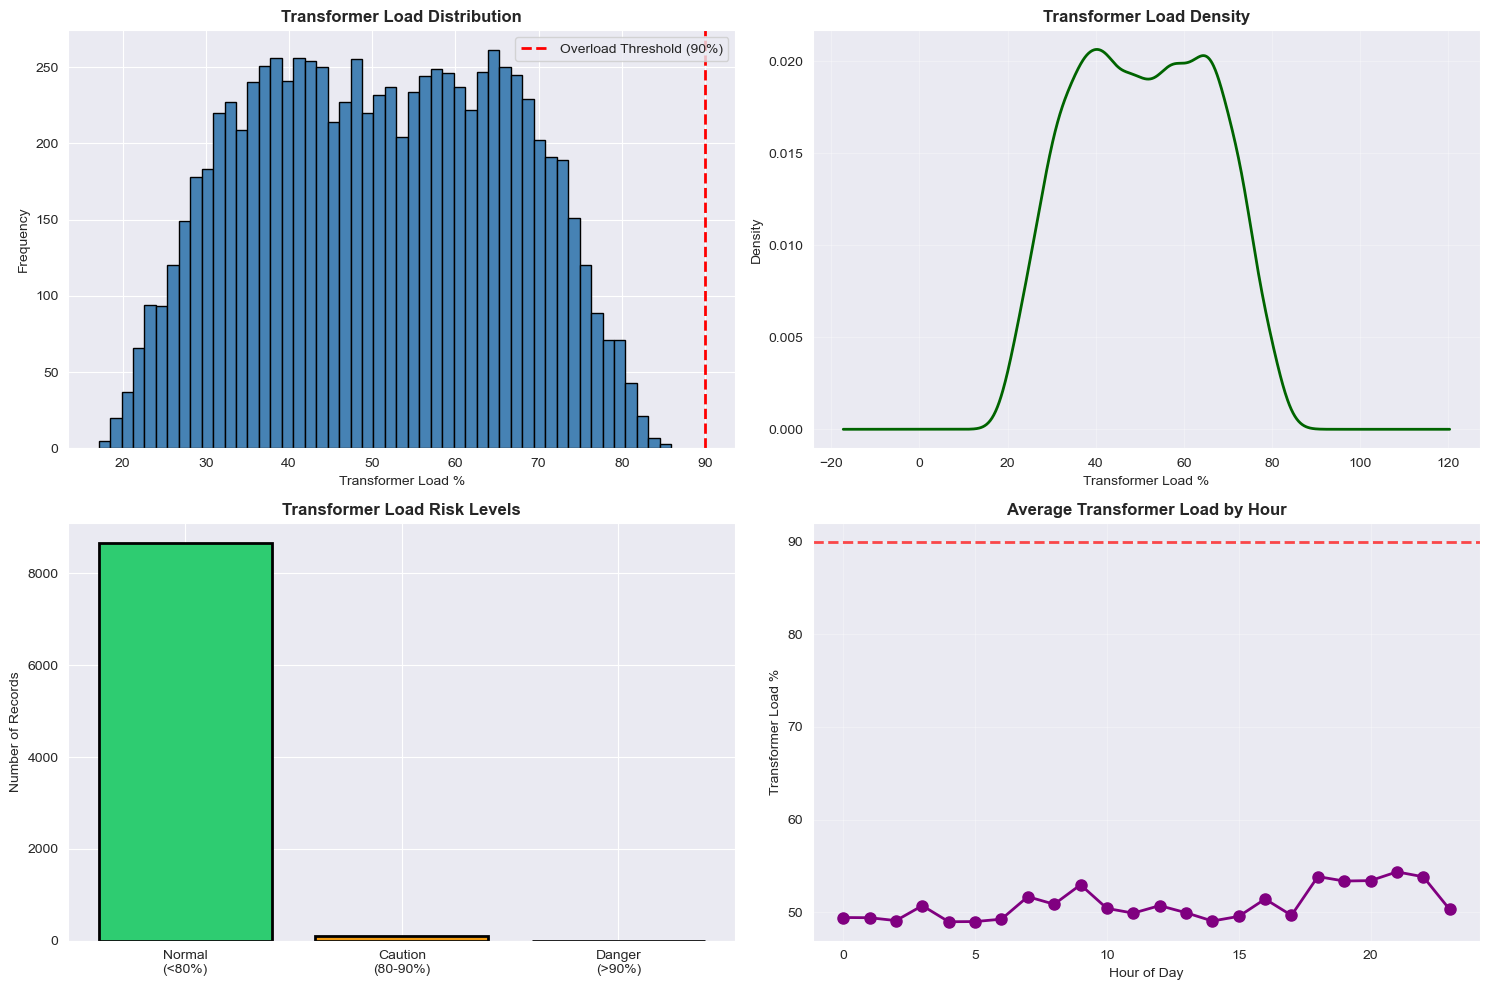

✓ Transformer Load Analysis Complete


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram: Transformer Load
axes[0, 0].hist(df_main['transformer_load_percent'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].axvline(90, color='red', linestyle='--', linewidth=2, label='Overload Threshold (90%)')
axes[0, 0].set_title('Transformer Load Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Transformer Load %')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# KDE plot
df_main['transformer_load_percent'].plot.kde(ax=axes[0, 1], color='darkgreen', linewidth=2)
axes[0, 1].set_title('Transformer Load Density', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Transformer Load %')
axes[0, 1].grid(True, alpha=0.3)

# Gauge chart representation
normal = len(df_main[df_main['transformer_load_percent'] < 80])
caution = len(df_main[(df_main['transformer_load_percent'] >= 80) & (df_main['transformer_load_percent'] < 90)])
danger = len(df_main[df_main['transformer_load_percent'] >= 90])

axes[1, 0].bar(['Normal\n(<80%)', 'Caution\n(80-90%)', 'Danger\n(>90%)'], 
               [normal, caution, danger], color=['#2ECC71', '#F39C12', '#E74C3C'], edgecolor='black', linewidth=2)
axes[1, 0].set_title('Transformer Load Risk Levels', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Records')

# Transformer load by hour
hourly_load = df_main.groupby('hour')['transformer_load_percent'].mean()
axes[1, 1].plot(hourly_load.index, hourly_load.values, marker='o', linewidth=2, color='purple', markersize=8)
axes[1, 1].axhline(90, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Average Transformer Load by Hour', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Transformer Load %')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Transformer Load Analysis Complete")

## 9. Correlation Heatmap

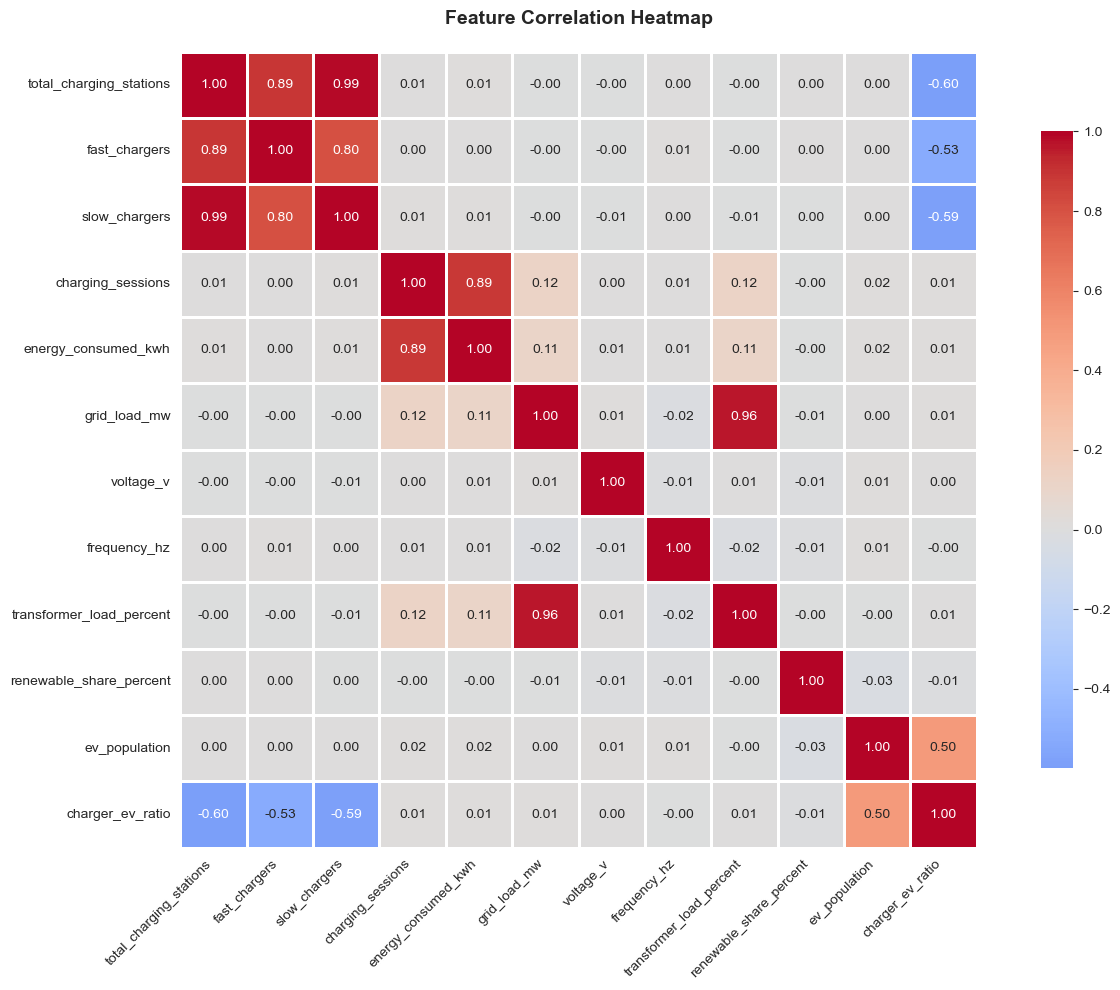


Top Correlations with Grid Load:
transformer_load_percent    0.959206
charging_sessions           0.122140
energy_consumed_kwh         0.111058
voltage_v                   0.010690
charger_ev_ratio            0.008605
Name: grid_load_mw, dtype: float64

✓ Correlation Analysis Complete


In [9]:
# Select numerical columns for correlation
numerical_cols = [
    'total_charging_stations', 'fast_chargers', 'slow_chargers',
    'charging_sessions', 'energy_consumed_kwh', 'grid_load_mw',
    'voltage_v', 'frequency_hz', 'transformer_load_percent',
    'renewable_share_percent', 'ev_population', 'charger_ev_ratio'
]

# Calculate correlation
correlation_matrix = df_main[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print top correlations with grid load
print("\nTop Correlations with Grid Load:")
grid_correlations = correlation_matrix['grid_load_mw'].sort_values(ascending=False)
print(grid_correlations[1:6])  # Exclude self-correlation

print("\n✓ Correlation Analysis Complete")

## 10. Time Series Grid Load Patterns

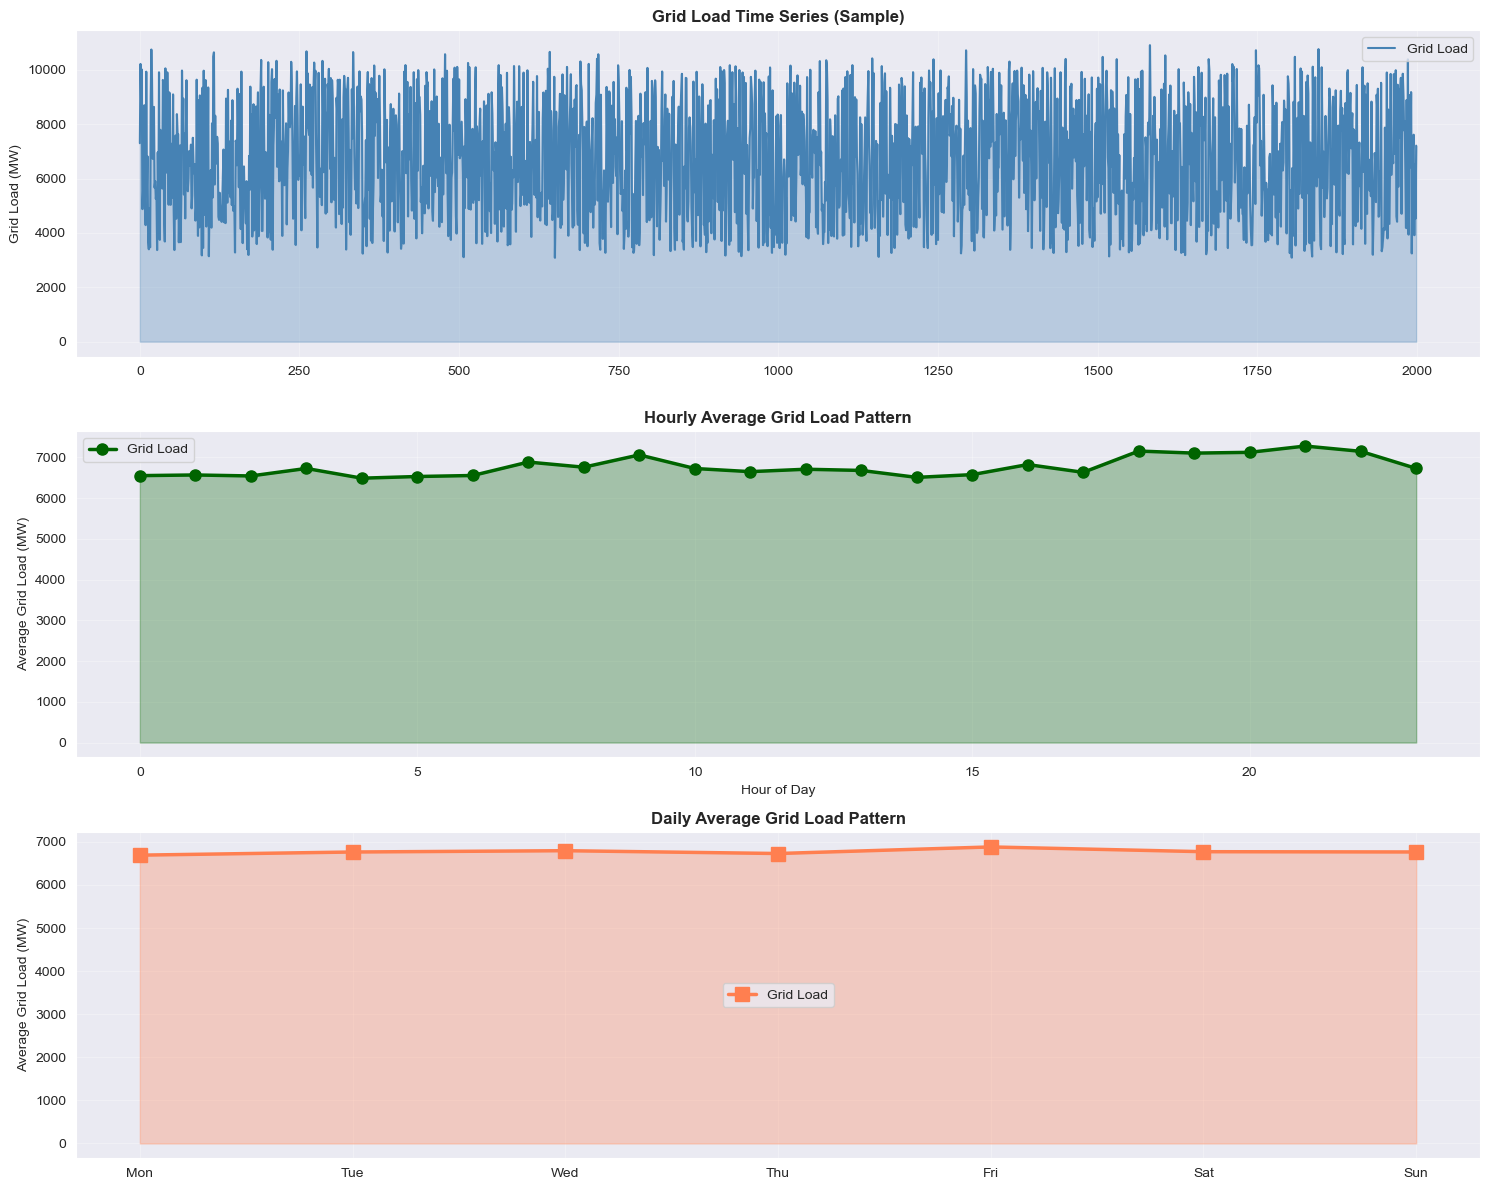

✓ Time Series Analysis Complete


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Time series for first 2000 records
axes[0].plot(df_main.index[:2000], df_main['grid_load_mw'].iloc[:2000], 
            linewidth=1.5, color='steelblue', label='Grid Load')
axes[0].fill_between(df_main.index[:2000], df_main['grid_load_mw'].iloc[:2000], 
                     alpha=0.3, color='steelblue')
axes[0].set_title('Grid Load Time Series (Sample)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Grid Load (MW)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hourly pattern
hourly_pattern = df_main.groupby('hour').agg({
    'grid_load_mw': 'mean',
    'charging_sessions': 'mean',
    'transformer_load_percent': 'mean'
})

axes[1].plot(hourly_pattern.index, hourly_pattern['grid_load_mw'], 
            marker='o', linewidth=2.5, markersize=8, color='darkgreen', label='Grid Load')
axes[1].fill_between(hourly_pattern.index, hourly_pattern['grid_load_mw'], 
                     alpha=0.3, color='darkgreen')
axes[1].set_title('Hourly Average Grid Load Pattern', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Grid Load (MW)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Daily pattern
daily_pattern = df_main.groupby('day_of_week').agg({
    'grid_load_mw': 'mean',
    'transformer_load_percent': 'mean'
})

days_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2].plot(daily_pattern.index, daily_pattern['grid_load_mw'], 
            marker='s', linewidth=2.5, markersize=10, color='coral', label='Grid Load')
axes[2].fill_between(daily_pattern.index, daily_pattern['grid_load_mw'], 
                     alpha=0.3, color='coral')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(days_names)
axes[2].set_title('Daily Average Grid Load Pattern', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Grid Load (MW)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("✓ Time Series Analysis Complete")

## 11. Overload Risk Distribution & Analysis

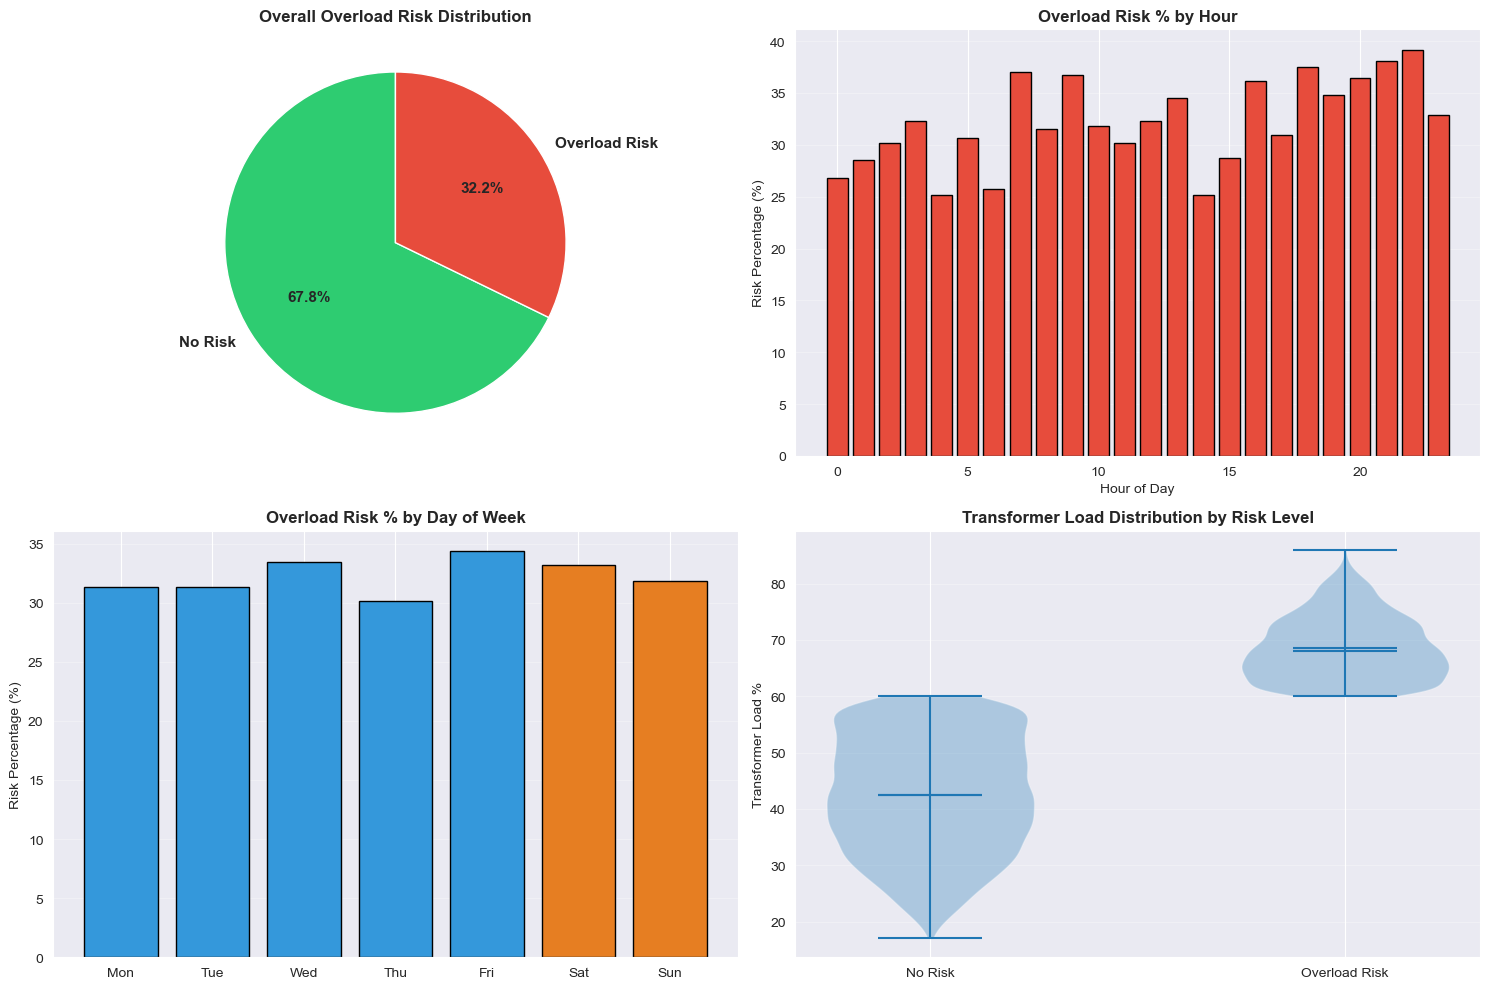


OVERLOAD RISK STATISTICS
Total Records: 8760
Records with Overload Risk: 2823 (32.23%)
Peak Hour Risk Rate: 33.34%
Off-Peak Hour Risk Rate: 29.51%

✓ Overload Risk Analysis Complete


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Risk distribution pie chart
risk_counts = df_main['overload_risk'].value_counts()
colors = ['#2ECC71', '#E74C3C']  # Green for no risk, Red for risk
labels = ['No Risk', 'Overload Risk']
axes[0, 0].pie(risk_counts.values, labels=labels, autopct='%1.1f%%', 
               colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[0, 0].set_title('Overall Overload Risk Distribution', fontsize=12, fontweight='bold')

# Risk by hour
hourly_risk = df_main.groupby('hour')['overload_risk'].apply(lambda x: (x.sum() / len(x)) * 100)
axes[0, 1].bar(hourly_risk.index, hourly_risk.values, color=['#E74C3C' if x > 20 else '#2ECC71' for x in hourly_risk.values], 
               edgecolor='black', linewidth=1)
axes[0, 1].set_title('Overload Risk % by Hour', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Risk Percentage (%)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Risk by day of week
daily_risk = df_main.groupby('day_of_week')['overload_risk'].apply(lambda x: (x.sum() / len(x)) * 100)
axes[1, 0].bar(daily_risk.index, daily_risk.values, color=['#3498DB' if i < 5 else '#E67E22' for i in daily_risk.index],
               edgecolor='black', linewidth=1)
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(days_names)
axes[1, 0].set_title('Overload Risk % by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Risk Percentage (%)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Transformer load comparison
risk_YES = df_main[df_main['overload_risk'] == 1]['transformer_load_percent']
risk_NO = df_main[df_main['overload_risk'] == 0]['transformer_load_percent']
axes[1, 1].violinplot([risk_NO, risk_YES], positions=[1, 2], showmeans=True, showmedians=True)
axes[1, 1].set_xticks([1, 2])
axes[1, 1].set_xticklabels(['No Risk', 'Overload Risk'])
axes[1, 1].set_title('Transformer Load Distribution by Risk Level', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Transformer Load %')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("OVERLOAD RISK STATISTICS")
print("="*60)
total_records = len(df_main)
risk_records = len(df_main[df_main['overload_risk'] == 1])
print(f"Total Records: {total_records}")
print(f"Records with Overload Risk: {risk_records} ({risk_records/total_records*100:.2f}%)")
print(f"Peak Hour Risk Rate: {hourly_risk[6:23].mean():.2f}%")
print(f"Off-Peak Hour Risk Rate: {hourly_risk[[0,1,2,3,4,5,23]].mean():.2f}%")
print("="*60)

print("\n✓ Overload Risk Analysis Complete")

## 12. Geographic Map: EV Charging Distribution by State

In [12]:
import folium
from folium import plugins
import requests

# State-level aggregation for mapping
state_stats = df_main.groupby('state').agg({
    'total_charging_stations': 'mean',
    'fast_chargers': 'mean',
    'slow_chargers': 'mean',
    'charging_sessions': 'mean',
    'grid_load_mw': 'mean',
    'transformer_load_percent': 'mean',
    'renewable_share_percent': 'mean',
    'overload_risk': lambda x: (x.sum() / len(x)) * 100
}).round(2)

state_stats.columns = ['Avg Stations', 'Avg Fast Chargers', 'Avg Slow Chargers', 
                       'Avg Sessions', 'Avg Grid Load (MW)', 'Avg Transformer Load %', 
                       'Renewable Share %', 'Risk %']

print("State-Level Statistics:")
print(state_stats.head(10))

# State coordinates for mapping
state_coords = {
    'Andhra Pradesh': [79.7400, 15.9129],
    'Arunachal Pradesh': [93.6100, 28.2180],
    'Assam': [91.7898, 26.2006],
    'Bihar': [85.3131, 25.0961],
    'Chhattisgarh': [81.6296, 21.2787],
    'Goa': [73.8278, 15.2993],
    'Gujarat': [72.6369, 22.2587],
    'Haryana': [77.0373, 29.0588],
    'Himachal Pradesh': [77.1734, 31.7894],
    'Jharkhand': [85.2799, 23.6102],
    'Karnataka': [75.7139, 15.3173],
    'Kerala': [76.2711, 10.8505],
    'Madhya Pradesh': [78.6569, 22.9375],
    'Maharashtra': [75.7139, 19.7515],
    'Manipur': [94.7868, 24.6637],
    'Meghalaya': [91.8960, 25.4670],
    'Mizoram': [93.9063, 23.1645],
    'Nagaland': [94.5614, 26.1584],
    'Odisha': [84.1239, 20.9517],
    'Punjab': [75.5941, 31.1471],
    'Rajasthan': [75.7139, 27.0238],
    'Sikkim': [88.5122, 27.5330],
    'Tamil Nadu': [78.6569, 11.1271],
    'Telangana': [78.4711, 18.1124],
    'Tripura': [91.9882, 23.9408],
    'Uttar Pradesh': [79.0193, 26.8467],
    'Uttarakhand': [79.0193, 30.0668],
    'West Bengal': [88.3639, 24.5155],
}

# Create base map centered on India
india_center = [20.5937, 78.9629]
m = folium.Map(location=india_center, zoom_start=5, tiles='OpenStreetMap')

# Add markers for each state with color coding based on risk
for state, coords in state_coords.items():
    if state in state_stats.index:
        risk_pct = state_stats.loc[state, 'Risk %']
        avg_sessions = state_stats.loc[state, 'Avg Sessions']
        avg_stations = state_stats.loc[state, 'Avg Stations']
        grid_load = state_stats.loc[state, 'Avg Grid Load (MW)']
        
        # Color based on risk level
        if risk_pct > 30:
            color = 'red'
            risk_label = '🔴 HIGH RISK'
        elif risk_pct > 15:
            color = 'orange'
            risk_label = '🟠 MEDIUM RISK'
        else:
            color = 'green'
            risk_label = '🟢 LOW RISK'
        
        # Popup information
        popup_text = f"""
        <b>{state}</b><br>
        {risk_label}<br>
        Risk Rate: {risk_pct:.1f}%<br>
        <hr>
        Avg Charging Stations: {avg_stations:.0f}<br>
        Avg Charging Sessions: {avg_sessions:.0f}<br>
        Avg Grid Load: {grid_load:.0f} MW<br>
        """
        
        folium.CircleMarker(
            location=coords,
            radius=10 + (risk_pct / 5),  # Size proportional to risk
            popup=folium.Popup(popup_text, max_width=300),
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.6,
            weight=2,
            tooltip=f"{state}: {risk_pct:.1f}% Risk"
        ).add_to(m)
        
        # Add state label
        folium.Marker(
            location=coords,
            popup=state,
            icon=folium.Icon(color='lightgray', icon='info-sign', prefix='glyphicon')
        ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 220px; height: 200px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px; border-radius: 5px;">
<p style="margin: 0; font-weight: bold; border-bottom: 1px solid grey; padding-bottom: 5px;">
EV Grid Risk Levels</p>
<p style="margin: 10px 0;">
<span style="color: green; font-weight: bold;">●</span> Low Risk (&lt;15%)
</p>
<p style="margin: 10px 0;">
<span style="color: orange; font-weight: bold;">●</span> Medium Risk (15-30%)
</p>
<p style="margin: 10px 0;">
<span style="color: red; font-weight: bold;">●</span> High Risk (&gt;30%)
</p>
<p style="margin: 10px 0; font-size: 12px; color: gray;">
Circle size indicates risk intensity
</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save and display
m.save('../data/ev_grid_risk_map.html')
print("\n✓ Interactive Map Created: ev_grid_risk_map.html")
print("Map saved to: ../data/ev_grid_risk_map.html")
m

State-Level Statistics:
                   Avg Stations  Avg Fast Chargers  Avg Slow Chargers  \
state                                                                   
Andhra Pradesh           366.47              91.13             275.35   
Arunachal Pradesh        387.17              96.44             290.72   
Assam                    358.80              91.64             267.16   
Bihar                    365.99              88.86             277.13   
Chhattisgarh             371.85              90.56             281.29   
Goa                      370.98              91.57             279.41   
Gujarat                  370.39              91.72             278.67   
Haryana                  395.99              98.41             297.59   
Himachal Pradesh         388.36              98.21             290.15   
Jharkhand                367.11              93.81             273.30   

                   Avg Sessions  Avg Grid Load (MW)  Avg Transformer Load %  \
state               

## 13. Interactive Charting: State-wise Metrics Comparison

In [15]:
# Create Plotly interactive charts
import plotly.graph_objects as go

# Sort states by risk
state_risk_sorted = state_stats.sort_values('Risk %', ascending=False)

# Interactive bar chart for top 15 states by risk
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=state_risk_sorted.head(15).index,
    y=state_risk_sorted.head(15)['Risk %'],
    marker=dict(
        color=state_risk_sorted.head(15)['Risk %'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(title="Risk %")
    ),
    text=state_risk_sorted.head(15)['Risk %'].round(1),
    textposition='auto',
    hovertemplate='<b>%{x}</b><br>Risk: %{y:.1f}%<extra></extra>'
))

fig1.update_layout(
    title='Top 15 States by Overload Risk %',
    xaxis_title='State',
    yaxis_title='Risk Percentage (%)',
    hovermode='x unified',
    height=500,
    template='plotly_white'
)
fig1.show()

# Interactive scatter: Grid Load vs Charging Sessions by State
fig2 = px.scatter(
    state_stats.reset_index(),
    x='Avg Sessions',
    y='Avg Grid Load (MW)',
    size='Avg Stations',
    color='Risk %',
    hover_name='state',
    color_continuous_scale='RdYlGn_r',
    size_max=40,
    title='State Analysis: Grid Load vs Charging Sessions',
    labels={'Avg Sessions': 'Average Charging Sessions',
            'Avg Grid Load (MW)': 'Average Grid Load (MW)',
            'Avg Stations': 'Avg Charging Stations',
            'Risk %': 'Risk %'}
)
fig2.update_layout(height=600, template='plotly_white')
fig2.show()

# Sunburst chart: Hierarchical view of states by risk levels
risk_categories = pd.cut(state_stats['Risk %'], bins=[0, 15, 30, 100], 
                          labels=['Low Risk', 'Medium Risk', 'High Risk'])

sunburst_data = state_stats.reset_index().copy()
sunburst_data['Risk Category'] = risk_categories.values

# Prepare hierarchical data for sunburst
hierarchy_data = sunburst_data[['state', 'Risk Category', 'Avg Stations', 'Risk %', 'Avg Grid Load (MW)']].copy()
hierarchy_data.columns = ['names', 'parents', 'values', 'color_val', 'load']

# Add root node
root_data = pd.DataFrame({
    'names': ['India'],
    'parents': [''],
    'values': [hierarchy_data['values'].sum()],
    'color_val': [sunburst_data['Risk %'].mean()],
    'load': [sunburst_data['Avg Grid Load (MW)'].mean()]
})

# Add category nodes
category_data = pd.DataFrame({
    'names': ['Low Risk', 'Medium Risk', 'High Risk'],
    'parents': ['India', 'India', 'India'],
    'values': [
        hierarchy_data[hierarchy_data['parents'] == 'Low Risk']['values'].sum(),
        hierarchy_data[hierarchy_data['parents'] == 'Medium Risk']['values'].sum(),
        hierarchy_data[hierarchy_data['parents'] == 'High Risk']['values'].sum()
    ],
    'color_val': [
        hierarchy_data[hierarchy_data['parents'] == 'Low Risk']['color_val'].mean(),
        hierarchy_data[hierarchy_data['parents'] == 'Medium Risk']['color_val'].mean(),
        hierarchy_data[hierarchy_data['parents'] == 'High Risk']['color_val'].mean()
    ],
    'load': [0, 0, 0]
})

# Combine all data
full_hierarchy = pd.concat([root_data, category_data, hierarchy_data], ignore_index=True)

fig3 = go.Figure(go.Sunburst(
    labels=full_hierarchy['names'],
    parents=full_hierarchy['parents'],
    values=full_hierarchy['values'],
    marker=dict(
        colors=full_hierarchy['color_val'],
        colorscale='RdYlGn_r',
        cmid=15,
        colorbar=dict(title="Risk %"),
        line=dict(color='white', width=2)
    ),
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Stations: %{value}<br>Risk: %{color:.1f}%<extra></extra>'
))

fig3.update_layout(
    title='Hierarchical View: States by Risk Category',
    height=600,
    template='plotly_white'
)
fig3.show()

print("\n✓ Interactive Charts Generated")
print("Note: Hover over charts for detailed information")


✓ Interactive Charts Generated
Note: Hover over charts for detailed information


## 14. Heatmap: State Risk Patterns by Hour

In [16]:
# Create heatmap of risk by state and hour
state_hour_risk = df_main.groupby(['state', 'hour']).agg({
    'overload_risk': lambda x: (x.sum() / len(x)) * 100,
    'transformer_load_percent': 'mean'
}).reset_index()

# Pivot for heatmap
heatmap_data = state_hour_risk.pivot_table(
    index='state',
    columns='hour',
    values='overload_risk',
    fill_value=0
)

# Create heatmap using Plotly
fig_heatmap = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns,
    y=heatmap_data.index,
    colorscale='RdYlGn_r',
    colorbar=dict(title="Risk %"),
    hovertemplate='<b>%{y}</b><br>Hour: %{x}:00<br>Risk: %{z:.1f}%<extra></extra>'
))

fig_heatmap.update_layout(
    title='Overload Risk % by State and Hour of Day',
    xaxis_title='Hour of Day',
    yaxis_title='State',
    height=800,
    width=1200,
    template='plotly_white'
)
fig_heatmap.show()

# Statistics
print("\nHigh Risk Hours by State (Most Dangerous Times):")
for state in heatmap_data.index:
    peak_hour = heatmap_data.loc[state].idxmax()
    peak_risk = heatmap_data.loc[state].max()
    print(f"  {state:20s}: Hour {peak_hour:2d}:00 ({peak_risk:5.1f}% risk)")

print("\n✓ Heatmap Analysis Complete")


High Risk Hours by State (Most Dangerous Times):
  Andhra Pradesh      : Hour 20:00 ( 62.5% risk)
  Arunachal Pradesh   : Hour  9:00 ( 50.0% risk)
  Assam               : Hour  9:00 ( 62.5% risk)
  Bihar               : Hour 20:00 ( 55.0% risk)
  Chhattisgarh        : Hour  6:00 ( 50.0% risk)
  Goa                 : Hour 18:00 ( 63.2% risk)
  Gujarat             : Hour 15:00 ( 55.6% risk)
  Haryana             : Hour 17:00 ( 62.5% risk)
  Himachal Pradesh    : Hour 20:00 ( 60.0% risk)
  Jharkhand           : Hour  1:00 ( 75.0% risk)
  Karnataka           : Hour  9:00 ( 63.6% risk)
  Kerala              : Hour 19:00 ( 60.0% risk)
  Madhya Pradesh      : Hour 18:00 ( 57.1% risk)
  Maharashtra         : Hour 10:00 ( 54.5% risk)
  Manipur             : Hour 20:00 ( 60.0% risk)
  Meghalaya           : Hour 22:00 ( 77.8% risk)
  Mizoram             : Hour 16:00 ( 78.6% risk)
  Nagaland            : Hour 11:00 ( 60.0% risk)
  Odisha              : Hour  9:00 ( 62.5% risk)
  Punjab           